Results saved to `benchmark_results/`

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────────
import os, json, time, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Create output directories
os.makedirs('benchmark_results/instances', exist_ok=True)
os.makedirs('benchmark_results/results', exist_ok=True)

print('Setup complete')
print(f'Output directory: {os.path.abspath("benchmark_results")}')

Setup complete
Output directory: C:\Users\PhotonUser\My Files\OneDrive\Files\Manzanillo\manzanillo-digital-twin\notebooks\benchmark_results


---
## Step 1: Generate Problem Instances
Creates JSON files for N=25, 50, 100 with:
- Sensor locations (synthetic if no CSV provided)
- Risk scores
- Distance matrix
- QUBO parameters

In [2]:
def haversine(lat1, lon1, lat2, lon2):
    """Distance in meters."""
    R = 6371000
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

def generate_instance(N, K, output_path):
    """Generate synthetic instance."""
    np.random.seed(42 + N)  # Different seed per N
    
    # Generate candidate locations around Manzanillo
    lats = np.random.uniform(19.03, 19.18, N)
    lons = np.random.uniform(-104.35, -104.15, N)
    
    # Risk scores (higher for "wildland" zones)
    base = np.random.uniform(0.3, 0.7, N)
    risk_norm = base / base.max()
    
    # Distance matrix
    dist = np.zeros((N, N))
    for i in range(N):
        for j in range(i+1, N):
            d = haversine(lats[i], lons[i], lats[j], lons[j])
            dist[i, j] = d
            dist[j, i] = d
    
    close_pairs = np.sum((dist > 0) & (dist < 500)) // 2
    
    instance = {
        "metadata": {
            "instance_name": f"manzanillo_N{N}_K{K}",
            "version": "1.0",
            "created_date": datetime.now().strftime("%Y-%m-%d"),
            "N": N,
            "K": K,
            "close_pairs": int(close_pairs)
        },
        "problem": {
            "N": N,
            "K_budget": K,
            "min_separation_m": 500.0,
            "lambda_budget": 5.0,
            "lambda_spatial": 8.0
        },
        "candidates": [
            {
                "id": i,
                "latitude": float(lats[i]),
                "longitude": float(lons[i]),
                "risk_score_norm": float(risk_norm[i])
            }
            for i in range(N)
        ],
        "distance_matrix": dist.tolist()
    }
    
    with open(output_path, 'w') as f:
        json.dump(instance, f, indent=2)
    
    print(f'✓ Generated {output_path} ({N} candidates, {K} budget, {close_pairs} close pairs)')
    return instance

# Generate 3 instances
instances = [
    generate_instance(25, 8, 'benchmark_results/instances/manzanillo_N25_K8.json'),
    generate_instance(50, 12, 'benchmark_results/instances/manzanillo_N50_K12.json'),
    generate_instance(100, 20, 'benchmark_results/instances/manzanillo_N100_K20.json')
]

✓ Generated benchmark_results/instances/manzanillo_N25_K8.json (25 candidates, 8 budget, 1 close pairs)
✓ Generated benchmark_results/instances/manzanillo_N50_K12.json (50 candidates, 12 budget, 2 close pairs)
✓ Generated benchmark_results/instances/manzanillo_N100_K20.json (100 candidates, 20 budget, 11 close pairs)


---
## Step 2: Define Solvers
Each solver takes an instance and returns a solution with coverage, runtime, violations.

In [3]:
def build_qubo(instance):
    """Build Q matrix from instance."""
    N = instance['problem']['N']
    K = instance['problem']['K_budget']
    lam_b = instance['problem']['lambda_budget']
    lam_s = instance['problem']['lambda_spatial']
    min_sep = instance['problem']['min_separation_m']
    
    r = np.array([c['risk_score_norm'] for c in instance['candidates']])
    dist = np.array(instance['distance_matrix'])
    
    Q = np.zeros((N, N))
    for i in range(N):
        Q[i, i] = -r[i] + lam_b * (1 - 2*K)
    for i in range(N):
        for j in range(i+1, N):
            Q[i, j] = 2 * lam_b
            if 0 < dist[i, j] < min_sep:
                Q[i, j] += 2 * lam_s
    
    return Q, r, dist

def qubo_energy(x, Q):
    return float(x @ Q @ x)

def count_violations(x, dist, min_sep):
    selected = np.where(x == 1)[0]
    viol = 0
    for i in selected:
        for j in selected:
            if i < j and 0 < dist[i, j] < min_sep:
                viol += 1
    return viol

# ── GREEDY ─────────────────────────────────────────────────────────────────────
def solve_greedy(instance):
    Q, r, dist = build_qubo(instance)
    K = instance['problem']['K_budget']
    
    t0 = time.time()
    indices = np.argsort(r)[::-1][:K]
    x = np.zeros(len(r), dtype=int)
    x[indices] = 1
    runtime = time.time() - t0
    
    return {
        'coverage': float(r[indices].sum()),
        'energy': float(qubo_energy(x, Q)),
        'violations': int(count_violations(x, dist, instance['problem']['min_separation_m'])),
        'runtime': runtime
    }

# ── SIMULATED ANNEALING ────────────────────────────────────────────────────────
def solve_sa(instance, seed=None, n_steps=50000):
    if seed is not None:
        np.random.seed(seed)
    
    Q, r, dist = build_qubo(instance)
    N = len(r)
    
    t0 = time.time()
    x = np.random.randint(0, 2, N)
    E = qubo_energy(x, Q)
    best_x, best_E = x.copy(), E
    
    temps = np.linspace(5.0, 0.01, n_steps)
    for T in temps:
        flip = np.random.randint(N)
        x_new = x.copy()
        x_new[flip] = 1 - x_new[flip]
        E_new = qubo_energy(x_new, Q)
        dE = E_new - E
        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            x, E = x_new, E_new
            if E < best_E:
                best_x, best_E = x.copy(), E
    
    runtime = time.time() - t0
    selected = np.where(best_x == 1)[0]
    
    return {
        'coverage': float(r[selected].sum() if len(selected) > 0 else 0),
        'energy': float(best_E),
        'violations': int(count_violations(best_x, dist, instance['problem']['min_separation_m'])),
        'runtime': runtime,
        'seed': seed
    }

# ── PENNYLANE QAOA (optional — comment out if pennylane not installed) ────────
def solve_qaoa(instance, seed=None, P=2, M=12, n_steps=40):
    try:
        import pennylane as qml
        from pennylane import numpy as pnp
    except ImportError:
        return {'error': 'PennyLane not installed'}
    
    if seed is not None:
        np.random.seed(seed)
    
    Q, r, dist = build_qubo(instance)
    N = instance['problem']['N']
    K = instance['problem']['K_budget']
    
    # Reduce to top-M
    M = min(M, N)
    top_M_idx = np.argsort(r)[::-1][:M]
    r_sub = r[top_M_idx]
    Q_sub = Q[np.ix_(top_M_idx, top_M_idx)]
    K_sub = max(1, int(K * M / N))
    
    # Ising
    def qubo_to_ising(Q):
        M = Q.shape[0]
        h = np.zeros(M)
        J = np.zeros((M, M))
        for i in range(M):
            h[i] += Q[i, i] / 2
            for j in range(i + 1, M):
                J[i, j] += Q[i, j] / 4
                h[i] += Q[i, j] / 4
                h[j] += Q[i, j] / 4
        return h, J
    
    h, J = qubo_to_ising(Q_sub)
    
    dev = qml.device('default.qubit', wires=M)
    
    def cost_h(h, J):
        coeffs, ops = [], []
        for i in range(len(h)):
            if abs(h[i]) > 1e-10:
                coeffs.append(h[i])
                ops.append(qml.PauliZ(i))
        for i in range(len(J)):
            for j in range(i + 1, len(J)):
                if abs(J[i, j]) > 1e-10:
                    coeffs.append(J[i, j])
                    ops.append(qml.PauliZ(i) @ qml.PauliZ(j))
        return qml.Hamiltonian(coeffs, ops)
    
    H_cost = cost_h(h, J)
    H_mixer = qml.Hamiltonian([-1.0]*M, [qml.PauliX(i) for i in range(M)])
    
    @qml.qnode(dev)
    def circuit(params):
        for i in range(M):
            qml.Hadamard(wires=i)
        for p in range(P):
            qml.CommutingEvolution(H_cost, params[p])
            qml.CommutingEvolution(H_mixer, params[P+p])
        return qml.expval(H_cost)
    
    dev_sample = qml.device('default.qubit', wires=M)
    
    @qml.qnode(dev_sample)
    def sample(params):
        for i in range(M):
            qml.Hadamard(wires=i)
        for p in range(P):
            qml.CommutingEvolution(H_cost, params[p])
            qml.CommutingEvolution(H_mixer, params[P+p])
        return qml.counts(all_outcomes=False)
    
    sample = qml.set_shots(sample, shots=2000)
    
    t0 = time.time()
    params = pnp.array(np.random.uniform(0, np.pi, 2*P), requires_grad=True)
    opt = qml.GradientDescentOptimizer(stepsize=0.1)
    for _ in range(n_steps):
        params, _ = opt.step_and_cost(circuit, params)
    
    counts = sample(params)
    
    best_bs, best_E = None, float('inf')
    for bs, _ in counts.items():
        x_sub = np.array([int(b) for b in (str(bs) if isinstance(bs, str) else list(bs))], dtype=int)
        if len(x_sub) == M and x_sub.sum() <= K_sub:
            E = qubo_energy(x_sub, Q_sub)
            if E < best_E:
                best_E = E
                best_bs = x_sub
    
    runtime = time.time() - t0
    
    if best_bs is not None:
        selected_sub = np.where(best_bs == 1)[0]
        selected_global = top_M_idx[selected_sub]
        x_full = np.zeros(N, dtype=int)
        x_full[selected_global] = 1
        
        return {
            'coverage': float(r[selected_global].sum()),
            'energy': float(qubo_energy(x_full, Q)),
            'violations': int(count_violations(x_full, dist, instance['problem']['min_separation_m'])),
            'runtime': runtime,
            'seed': seed,
            'note': f'Subproblem M={M}'
        }
    else:
        return {'error': 'No valid solution', 'runtime': runtime}

print('✓ Solvers defined: greedy, simulated_annealing, pennylane_qaoa')

✓ Solvers defined: greedy, simulated_annealing, pennylane_qaoa


---
## Step 3: Run Benchmarks
Runs each solver on each instance with 5 seeds (except Greedy which is deterministic).

In [4]:
results = []

for inst_path in ['benchmark_results/instances/manzanillo_N25_K8.json',
                   'benchmark_results/instances/manzanillo_N50_K12.json',
                   'benchmark_results/instances/manzanillo_N100_K20.json']:
    
    with open(inst_path) as f:
        instance = json.load(f)
    
    N = instance['metadata']['N']
    K = instance['metadata']['K']
    
    print(f'\n{"="*60}')
    print(f'Running N={N}, K={K}')
    print(f'{"="*60}')
    
    # Greedy (1 run)
    print('  Greedy...', end=' ')
    res_greedy = solve_greedy(instance)
    print(f'coverage={res_greedy["coverage"]:.4f}, runtime={res_greedy["runtime"]*1000:.1f}ms')
    results.append({'N': N, 'K': K, 'solver': 'Greedy', 'seed': 0, **res_greedy})
    
    # Simulated Annealing (5 seeds)
    print('  Simulated Annealing (5 seeds)...')
    for seed in range(5):
        res = solve_sa(instance, seed=seed)
        print(f'    seed {seed}: coverage={res["coverage"]:.4f}, runtime={res["runtime"]:.2f}s')
        results.append({'N': N, 'K': K, 'solver': 'SA', 'seed': seed, **res})
    
    # PennyLane QAOA (5 seeds, only for N=25 to save time)
    if N == 25:
        print('  PennyLane QAOA (5 seeds, M=12)...')
        for seed in range(5):
            res = solve_qaoa(instance, seed=seed, M=12)
            if 'error' in res:
                print(f'    seed {seed}: {res["error"]}')
            else:
                print(f'    seed {seed}: coverage={res["coverage"]:.4f}, runtime={res["runtime"]:.2f}s')
            results.append({'N': N, 'K': K, 'solver': 'QAOA', 'seed': seed, **res})
    else:
        print('  Skipping QAOA for N>25 (too slow on CPU)')

print(f'\n✓ Benchmarks complete: {len(results)} runs')


Running N=25, K=8
  Greedy... coverage=7.1166, runtime=0.1ms
  Simulated Annealing (5 seeds)...
    seed 0: coverage=6.7969, runtime=1.07s
    seed 1: coverage=6.8775, runtime=1.04s
    seed 2: coverage=6.8125, runtime=0.95s
    seed 3: coverage=6.8281, runtime=0.94s
    seed 4: coverage=6.9843, runtime=1.47s
  PennyLane QAOA (5 seeds, M=12)...
    seed 0: coverage=2.9091, runtime=18.76s
    seed 1: coverage=2.9091, runtime=17.81s
    seed 2: coverage=2.8088, runtime=17.18s
    seed 3: coverage=2.9091, runtime=16.72s
    seed 4: coverage=2.9091, runtime=17.74s

Running N=50, K=12
  Greedy... coverage=11.4523, runtime=0.0ms
  Simulated Annealing (5 seeds)...
    seed 0: coverage=10.7410, runtime=1.03s
    seed 1: coverage=10.3596, runtime=0.99s
    seed 2: coverage=10.5388, runtime=1.00s
    seed 3: coverage=10.2598, runtime=1.00s
    seed 4: coverage=10.7860, runtime=0.99s
  Skipping QAOA for N>25 (too slow on CPU)

Running N=100, K=20
  Greedy... coverage=18.6365, runtime=0.0ms
  Sim

---
## Step 4: Aggregate Results & Create Comparison Table

In [5]:
df_results = pd.DataFrame(results)

# Filter out errors
df_valid = df_results[~df_results['coverage'].isna()].copy()

# Aggregate by (N, solver)
agg = df_valid.groupby(['N', 'solver']).agg({
    'coverage': ['mean', 'std', 'max'],
    'runtime': ['mean', 'std'],
    'violations': ['mean', 'std'],
    'energy': ['mean', 'std']
}).reset_index()

# Flatten column names
agg.columns = ['_'.join(col).strip('_') for col in agg.columns.values]

# Pretty print
print('\n' + '='*80)
print('BENCHMARK COMPARISON TABLE')
print('='*80)
print(agg.to_string(index=False))

# Save
agg.to_csv('benchmark_results/comparison_table.csv', index=False)
df_results.to_csv('benchmark_results/all_runs.csv', index=False)
print(f'\n✓ Saved: benchmark_results/comparison_table.csv')
print(f'✓ Saved: benchmark_results/all_runs.csv')


BENCHMARK COMPARISON TABLE
  N solver  coverage_mean  coverage_std  coverage_max  runtime_mean  runtime_std  violations_mean  violations_std  energy_mean  energy_std
 25 Greedy       7.116562           NaN      7.116562      0.000066          NaN              0.0             NaN  -327.116562         NaN
 25   QAOA       2.889006      0.044862      2.909069     17.640941     0.767542              0.0             0.0  -197.889006    0.044862
 25     SA       6.859870      0.075874      6.984345      1.094649     0.217709              0.0             0.0  -326.859870    0.075874
 50 Greedy      11.452310           NaN     11.452310      0.000031          NaN              0.0             NaN  -731.452310         NaN
 50     SA      10.537043      0.230164     10.786034      0.999558     0.018092              0.0             0.0  -730.537043    0.230164
100 Greedy      18.636493           NaN     18.636493      0.000035          NaN              0.0             NaN -2018.636493         NaN

---
## Step 5: Visualizations

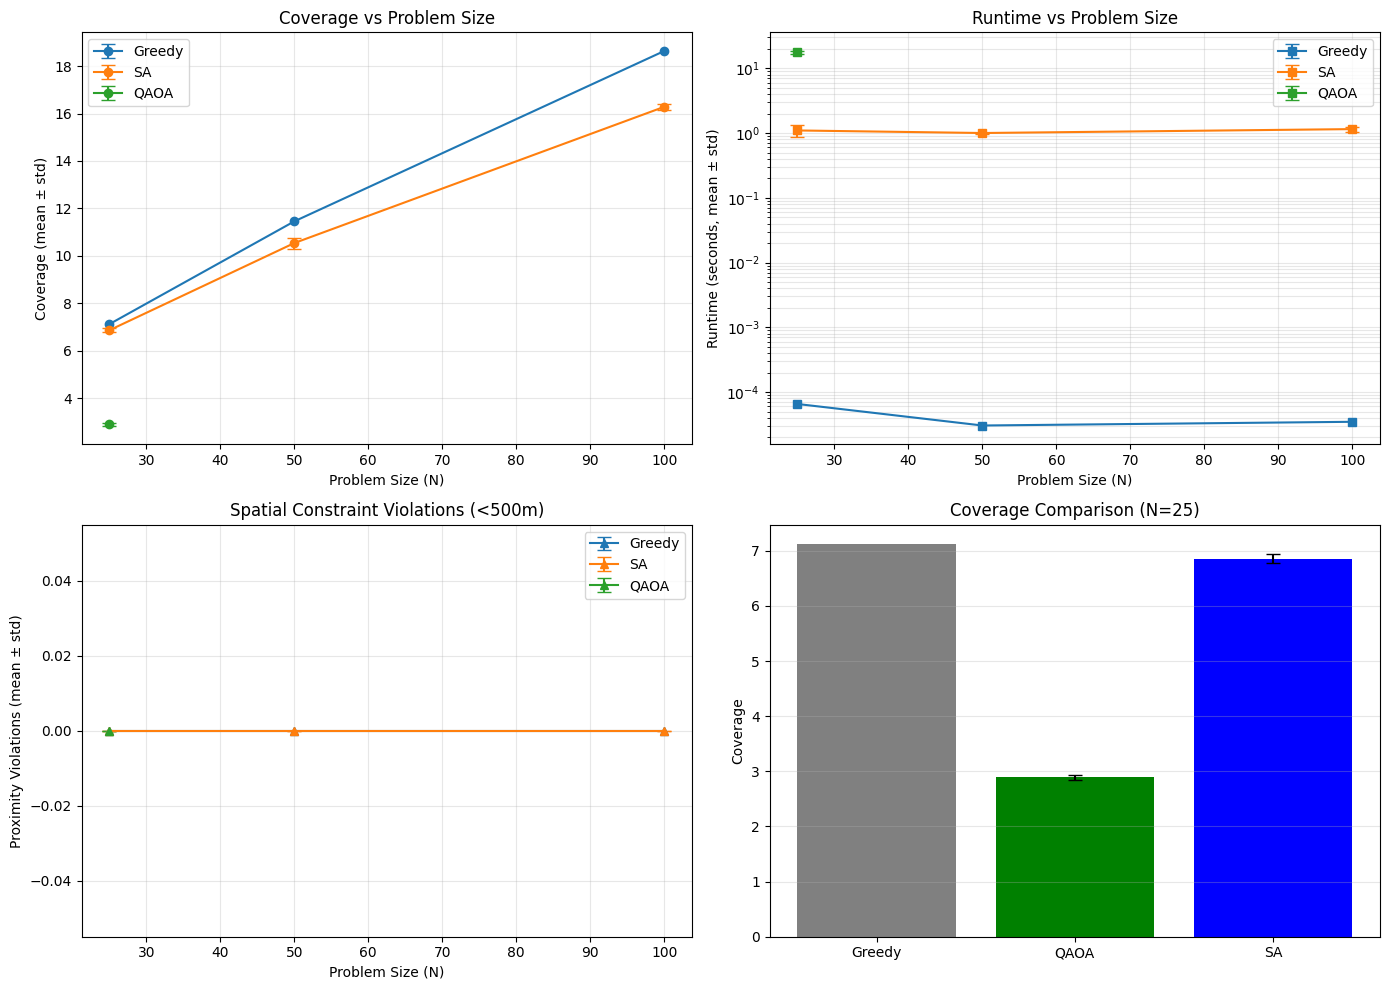

✓ Saved: benchmark_results/scaling_plots.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Coverage vs N
for solver in ['Greedy', 'SA', 'QAOA']:
    data = agg[agg['solver'] == solver]
    if len(data) > 0:
        axes[0, 0].errorbar(data['N'], data['coverage_mean'], yerr=data['coverage_std'],
                           marker='o', label=solver, capsize=5)
axes[0, 0].set_xlabel('Problem Size (N)')
axes[0, 0].set_ylabel('Coverage (mean ± std)')
axes[0, 0].set_title('Coverage vs Problem Size')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Plot 2: Runtime vs N
for solver in ['Greedy', 'SA', 'QAOA']:
    data = agg[agg['solver'] == solver]
    if len(data) > 0:
        axes[0, 1].errorbar(data['N'], data['runtime_mean'], yerr=data['runtime_std'],
                           marker='s', label=solver, capsize=5)
axes[0, 1].set_xlabel('Problem Size (N)')
axes[0, 1].set_ylabel('Runtime (seconds, mean ± std)')
axes[0, 1].set_title('Runtime vs Problem Size')
axes[0, 1].set_yscale('log')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3, which='both')

# Plot 3: Violations vs N
for solver in ['Greedy', 'SA', 'QAOA']:
    data = agg[agg['solver'] == solver]
    if len(data) > 0:
        axes[1, 0].errorbar(data['N'], data['violations_mean'], yerr=data['violations_std'],
                           marker='^', label=solver, capsize=5)
axes[1, 0].set_xlabel('Problem Size (N)')
axes[1, 0].set_ylabel('Proximity Violations (mean ± std)')
axes[1, 0].set_title('Spatial Constraint Violations (<500m)')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Plot 4: Bar chart for N=25
n25_data = agg[agg['N'] == 25]
x_pos = np.arange(len(n25_data))
axes[1, 1].bar(x_pos, n25_data['coverage_mean'], yerr=n25_data['coverage_std'],
              capsize=5, color=['gray', 'green', 'blue'])
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(n25_data['solver'])
axes[1, 1].set_ylabel('Coverage')
axes[1, 1].set_title('Coverage Comparison (N=25)')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('benchmark_results/scaling_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved: benchmark_results/scaling_plots.png')

**What you got:**
1. `benchmark_results/instances/` 3 standardized JSON problem files (N=25, 50, 100)
2. `benchmark_results/all_runs.csv` Raw results from all solver runs
3. `benchmark_results/comparison_table.csv` Aggregated mean±std by solver and N
4. `benchmark_results/scaling_plots.png` 4-panel visualization